# Global Weather File Cleaning
---

## Table of Contents
1. [Load Data](#1-load-data)
2. [Select Columns](#2-select-columns)
3. [Data Validation](#3-data-validation)
4. [Translate Country Names](#4-translate-country-names)
5. [Standardise & Check for Duplicates](#5-standardise--check-for-duplicates)
6. [Drop Duplicates](#6-drop-duplicates)
7. [Map Weather Conditions](#7-map-weather-conditions)
8. [Calculate Daylight Hours](#8-calculate-daylight-hours)
9. [Range Validation](#9-range-validation)
10. [Final Dataset Preview and checks](#10-final-dataset-preview-and-checks)
11. [Multivariate Assessment for Index Integration](#11-multivariate-assessment-for-index-integration)
12. [Data Source](#12-data-source)
13. [References](#13-references)


## 1. Load Data
The raw dataset is loaded from CSV and the first 10 rows are displayed to help get a feel of what data is in the set as well as the data type.

In [21]:
# Importing the weather CSV file and display the first 10 rows of the dataset.
import pandas as pd
weather = pd.read_csv('../Raw_Csvs/Global_Weather_Repository.csv')
weather.head(10)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
5,Antigua and Barbuda,Saint John's,17.12,-61.85,America/Antigua,1715849100,2024-05-16 04:45,26.0,78.8,Partly cloudy,...,1.2,4.5,1,1,05:36 AM,06:32 PM,01:05 PM,01:14 AM,Waxing Gibbous,55
6,Argentina,Buenos Aires,-34.59,-58.67,America/Argentina/Buenos_Aires,1715849100,2024-05-16 05:45,8.0,46.4,Clear,...,4.0,5.3,1,1,07:43 AM,05:59 PM,02:36 PM,01:04 AM,Waxing Gibbous,55
7,Armenia,Yerevan,40.18,44.51,Asia/Yerevan,1715849100,2024-05-16 12:45,19.0,66.2,Partly cloudy,...,0.8,0.9,1,1,05:45 AM,08:12 PM,01:17 PM,02:31 AM,Waxing Gibbous,55
8,Australia,Canberra,-35.28,149.22,Australia/Sydney,1715849100,2024-05-16 18:45,9.0,48.2,Clear,...,3.7,5.4,1,1,06:52 AM,05:07 PM,01:31 PM,No moonset,Waxing Gibbous,55
9,Austria,Vienna,48.20,16.37,Europe/Vienna,1715849100,2024-05-16 10:45,16.0,60.8,Partly cloudy,...,3.7,4.4,1,1,05:14 AM,08:29 PM,01:00 PM,02:42 AM,Waxing Gibbous,55


## 2. Select Columns
Only the columns relevant to a holiday destination comparison are kept.

In [22]:
# Keeping only the columns that I want to use for the analysis.
weather_cols = ['country', 'temperature_celsius', 'condition_text', 'wind_kph', 'humidity', 'uv_index', 'sunrise', 'sunset']
weather_clean = weather
weather_clean = weather_clean[weather_cols].copy()
weather_clean.head(10)


,country,temperature_celsius,condition_text,wind_kph,humidity,uv_index,sunrise,sunset
0,Afghanistan,26.6,Partly Cloudy,13.3,24,7.0,04:50 AM,06:50 PM
1,Albania,19.0,Partly cloudy,11.2,94,5.0,05:21 AM,07:54 PM
2,Algeria,23.0,Sunny,15.1,29,5.0,05:40 AM,07:50 PM
3,Andorra,6.3,Light drizzle,11.9,61,2.0,06:31 AM,09:11 PM
4,Angola,26.0,Partly cloudy,13.0,89,8.0,06:12 AM,05:55 PM
5,Antigua and Barbuda,26.0,Partly cloudy,9.0,84,1.0,05:36 AM,06:32 PM
6,Argentina,8.0,Clear,3.6,93,1.0,07:43 AM,05:59 PM
7,Armenia,19.0,Partly cloudy,6.8,40,4.0,05:45 AM,08:12 PM
8,Australia,9.0,Clear,4.0,87,1.0,06:52 AM,05:07 PM
9,Austria,16.0,Partly cloudy,20.2,63,5.0,05:14 AM,08:29 PM


## 3. Data Validation
Check for missing/blank values and confirm each column holds the expected data type before any transformations are applied.

In [23]:
# Check every column for missing or blank values
print("Missing value counts per column:")
print("-" * 40)
print(f"country:              {weather_clean['country'].isna().sum()} NaN  |  {(weather_clean['country'] == '').sum()} blank")
print(f"temperature_celsius:  {weather_clean['temperature_celsius'].isna().sum()} NaN  |  {(weather_clean['temperature_celsius'] == '').sum()} blank")
print(f"condition_text:       {weather_clean['condition_text'].isna().sum()} NaN  |  {(weather_clean['condition_text'] == '').sum()} blank")
print(f"wind_kph:             {weather_clean['wind_kph'].isna().sum()} NaN  |  {(weather_clean['wind_kph'] == '').sum()} blank")
print(f"humidity:             {weather_clean['humidity'].isna().sum()} NaN  |  {(weather_clean['humidity'] == '').sum()} blank")
print(f"uv_index:             {weather_clean['uv_index'].isna().sum()} NaN  |  {(weather_clean['uv_index'] == '').sum()} blank")
print(f"sunrise:              {weather_clean['sunrise'].isna().sum()} NaN  |  {(weather_clean['sunrise'] == '').sum()} blank")
print(f"sunset:               {weather_clean['sunset'].isna().sum()} NaN  |  {(weather_clean['sunset'] == '').sum()} blank")


Missing value counts per column:
----------------------------------------
country:              0 NaN  |  0 blank
temperature_celsius:  0 NaN  |  0 blank
condition_text:       0 NaN  |  0 blank
wind_kph:             0 NaN  |  0 blank
humidity:             0 NaN  |  0 blank
uv_index:             0 NaN  |  0 blank
sunrise:              0 NaN  |  0 blank
sunset:               0 NaN  |  0 blank


In [24]:
# Confirm that each column holds the type of data I actually expect
# Text columns should be strings, measurement columns should be numeric
print("Data Type Validation:")
print("-" * 40)

for col in ['country', 'condition_text']:
    valid = weather_clean[col].apply(lambda x: isinstance(x, str)).all()
    print(f"{col}: all strings = {valid}")

for col in ['temperature_celsius', 'wind_kph', 'humidity', 'uv_index']:
    valid = weather_clean[col].apply(lambda x: isinstance(x, (int, float))).all()
    print(f"{col}: all numeric = {valid}")

print("-" * 40)


Data Type Validation:
----------------------------------------
country: all strings = True
condition_text: all strings = True
temperature_celsius: all numeric = True
wind_kph: all numeric = True
humidity: all numeric = True
uv_index: all numeric = True
----------------------------------------


In [25]:
# Humidity can't be below 0%, UV index can't be negative, wind speed can't be negative.
print("Negative value check:")
print("-" * 40)
for col in ['wind_kph', 'humidity', 'uv_index']:
    neg_count = (weather_clean[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")
print("-" * 40)


Negative value check:
----------------------------------------
wind_kph: 0 negative values
humidity: 0 negative values
uv_index: 0 negative values
----------------------------------------


## 4. Translate Country Names
Country names are detected by Unicode script, then all non-English names are auto-translated to English using Google Translate.

In [26]:
import unicodedata
from deep_translator import GoogleTranslator

# Used ChatGPT to help write this code, but went through each line to understand it
# and commented on it throughout to make sure I know exactly what it's doing and why, 
# and to clarify the

# ---------------------------------------------------------------------------
# STEP 1: Detect the writing script of each country name
# ---------------------------------------------------------------------------
# The data set contains country names in various different languages and scripts, so
# I first need to figure out which script and language each name is written in.
#
# This function inspects each character in a country name using Unicode metadata.
# Unicode assigns every character a name (e.g. "ARABIC LETTER AIN"), so I can
# use the start of that name to classify the script.

def detect_script(text):
    scripts = set()
    for char in text:
        if char.isspace() or char in "-',.()'":
            continue
        try:
            name = unicodedata.name(char, '')
            if name.startswith('ARABIC'):                           scripts.add('Arabic')
            elif name.startswith(('CJK', 'HIRAGANA', 'KATAKANA')): scripts.add('CJK / Japanese / Chinese')
            elif name.startswith('CYRILLIC'):                       scripts.add('Cyrillic')
            elif char.isascii() and char.isalpha():                 scripts.add('English')

            # -------------------------------------------------------------------
            # WHY "Other" appears in the output
            # -------------------------------------------------------------------
            # char.isascii() returns False for accented Latin characters such as:
            #   á  (U+00E1)  used in Portuguese "Malásia"
            #   é  (U+00E9)  used in French/Portuguese "Bélgica", "Turkménistan"
            #   ô  (U+00F4)  used in Brazilian Portuguese "Polônia"
            #   ü  (U+00FC)  used in German "Südkorea"
            #
            # These characters ARE alphabetic (char.isalpha() = True), so they
            # fall into this else branch instead of being labelled 'English'.
            # Their Unicode names all begin with "LATIN SMALL LETTER ...", which
            # doesn't match any of the earlier checks (Arabic, CJK, Cyrillic),
            # so they are bucketed as "Other" with the Unicode code point printed
            # for transparency — e.g. "Other (U+00E1: LATIN SMALL LETTER A WITH ACUT)".
            # -------------------------------------------------------------------
            
            elif char.isalpha():                                    scripts.add(f'Other (U+{ord(char):04X}: {name[:30]})')
        except Exception:
            scripts.add('Unknown')
    return scripts

# ---------------------------------------------------------------------------
# STEP 2: Group every country name by its detected script
# ---------------------------------------------------------------------------
# I iterate over all country values and bucket them by script/language.
# This gives a clear picture of how many non-English names need translating.
script_to_countries = {}
for country in weather_clean['country']:
    for script in detect_script(country):
        script_to_countries.setdefault(script, []).append(country)

# ---------------------------------------------------------------------------
# STEP 3: Translate all non-English country names into English
# ---------------------------------------------------------------------------
# I then use GoogleTranslator (from the deep-translator library) with auto source
# detection, so I don't need to know the exact language up front because Google
# figures it out for me. The result is .title()-cased to be consistent with all other
# country names that are already in English.
#
# Translations are stored in a dictionary (translation_map) so I can apply
# them all at once to the dataframe in a single .replace() call at the end,
# rather than modifying rows one by one.
translator = GoogleTranslator(source='auto', target='en')
translation_map = {}

print("Scripts detected in country names:")
print("=" * 50)
for script, countries in sorted(script_to_countries.items()):
    print(f"\n{script} ({len(countries)} {'country' if len(countries) == 1 else 'countries'}):")
    if script != 'English':
        print("-" * 40)
        for country in countries:
            try:
                translated = translator.translate(country).title()
                translation_map[country] = translated
                print(f"  Original : {country}")
                print(f"  English  : {translated}\n")
            except Exception as e:
                print(f"  {country}  ->  (translation failed: {e})")

# ---------------------------------------------------------------------------
# STEP 4: Apply the translations back into the dataframe
# ---------------------------------------------------------------------------
# Now that I have a full mapping of English names, I replace them in one go.
weather_clean['country'] = weather_clean['country'].replace(translation_map)


Scripts detected in country names:

Arabic (1 country):
----------------------------------------
  Original : كولومبيا
  English  : Colombia


CJK / Japanese / Chinese (1 country):
----------------------------------------
  Original : 火鸡
  English  : Turkey


Cyrillic (3 countries):
----------------------------------------
  Original : Гватемала
  English  : Guatemala

  Original : Польша
  English  : Poland

  Original : Турция
  English  : Turkey


English (135653 countries):

Other (U+00E1: LATIN SMALL LETTER A WITH ACUT) (1 country):
----------------------------------------
  Original : Malásia
  English  : Malaysia


Other (U+00E9: LATIN SMALL LETTER E WITH ACUT) (2 countries):
----------------------------------------
  Original : Bélgica
  English  : Belgium

  Original : Turkménistan
  English  : Turkmenistan


Other (U+00F4: LATIN SMALL LETTER O WITH CIRC) (1 country):
----------------------------------------
  Original : Polônia
  English  : Poland


Other (U+00FC: LATIN SMALL

## 5. Standardise & Check for Duplicates
Country names are title-cased for consistency, then unique value counts are checked across `country` and `condition_text`.

In [27]:
# Quick check to see if any duplicate values are present 
# Quick standardization step to ensure consistent capitalization before checking for duplicates
weather_clean['country'] = weather_clean['country'].str.title() 
for col in ['country', 'condition_text']:
    print(f"--- Column: {col} ---")
    print(f"Total Unique Values: {weather_clean[col].nunique()}")
    print(f"Total Rows: {len(weather_clean[col])}")
    print("-" * 30)


--- Column: country ---
Total Unique Values: 201
Total Rows: 135658
------------------------------
--- Column: condition_text ---
Total Unique Values: 49
Total Rows: 135658
------------------------------


## 6. Handeling Duplicates
The dataset has multiple rows per country. Each represents an entry per day. I want to get the average expected value for each column.
The data starts from August 29th 2023 according to the data brief. In order to get the average yearly conditions i will calculate the next 365
entries and get the mean and mode representing the country on a year long basis.

In [28]:
# Keep only the first 365 daily records per country (starting from 2023-08-29 in source data),
# then aggregate to one representative row per country.
first_year_per_country = weather_clean.groupby('country', sort=False).head(365).copy()

# Mean is used for numeric weather features because it summarizes annual level well.
numeric_cols = ['temperature_celsius', 'wind_kph', 'humidity', 'uv_index']
mode_cols = ['condition_text', 'sunrise', 'sunset']

agg_dict = {col: 'mean' for col in numeric_cols}
agg_dict.update({col: lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0] for col in mode_cols})

weather_clean = (
    first_year_per_country
    .groupby('country', as_index=False)
    .agg(agg_dict)
    .sort_values('country')
    .reset_index(drop=True)
)

print(f"Rows after one-year country aggregation: {len(weather_clean)}")
print(weather_clean['country'].tolist())

Rows after one-year country aggregation: 201
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua And Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia And Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Cote D'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Democratic Republic Of Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Estonie', 'Ethiopia', 'Fiji Islands', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', '

## 7. Map Weather Conditions
The raw `condition_text` values are too granular. They are collapsed into 6 broad categories: **Clear, Partly Cloudy, Cloudy, Fog, Rain, Thunderstorm**.

In [29]:
# Standardise condition_text to lowercase and strip whitespace before any mapping,
# so that variations like "Partly Cloudy" and "Partly cloudy" resolve to the same key.
weather_clean['condition_text'] = weather_clean['condition_text'].str.strip().str.lower()

weather = weather_clean['condition_text'].unique()

# -----------Before mapping to broader categories -----------
# First, I want to see all the raw condition labels so I can decide
#  on general categories to bucket them into.
print(f"Total unique condition_text values: {len(weather)}")
print("-" * 40)
for condition in sorted(weather):
    count = (weather_clean['condition_text'] == condition).sum()
    print(f"{condition}: {count}")

# -----------After mapping to broader categories -----------
# The raw conditions are too granular e.g. Light rain,Moderate rain etc...
# I collapse them into 6 broad categories that are more meaningful for
# comparing holiday destinations at a high level.
condition_map = {
    # Clear
    'clear': 'Clear', 'sunny': 'Clear',
    # Partly Cloudy  
    'partly cloudy': 'Partly Cloudy',
    # Cloudy
    'cloudy': 'Cloudy', 'overcast': 'Cloudy',
    # Fog
    'fog': 'Fog', 'mist': 'Fog',
    # Rain
    'light drizzle': 'Rain', 'light rain': 'Rain', 'light rain shower': 'Rain',
    'moderate rain': 'Rain', 'moderate rain at times': 'Rain',
    'patchy light drizzle': 'Rain', 'patchy rain nearby': 'Rain',
    # Thunderstorm
    'moderate or heavy rain with thunder': 'Thunderstorm',
    'patchy light rain in area with thunder': 'Thunderstorm',
    'patchy light rain with thunder': 'Thunderstorm',
}

weather_clean['condition_category'] = weather_clean['condition_text'].map(condition_map)

print(f"\nTotal unique condition categories after combining: {weather_clean['condition_category'].nunique()}")
print("-" * 40)
category_counts = weather_clean['condition_category'].value_counts().sort_index()
for category, count in category_counts.items():
    print(f"{category}: {count}")

# Any NaN here means a condition_text value wasn't in the map
print(f"\nUnmapped values: {weather_clean['condition_category'].isna().sum()}")

Total unique condition_text values: 9
----------------------------------------
clear: 10
fog: 1
light rain shower: 3
mist: 3
overcast: 2
partly cloudy: 94
patchy light drizzle: 1
patchy rain nearby: 11
sunny: 76

Total unique condition categories after combining: 5
----------------------------------------
Clear: 86
Cloudy: 2
Fog: 4
Partly Cloudy: 94
Rain: 15

Unmapped values: 0


## 7.1 — Ordinal Encode condition_category

The broad weather categories are converted to a numeric ordinal score so they can be used directly in the composite index without any further encoding in downstream notebooks.

| Category | Score | Rationale |
|---|---|---|
| Thunderstorm | 0 | Severe — actively dangerous for outdoor activity |
| Rain | 1 | Poor — likely to disrupt most holiday plans |
| Fog | 2 | Limiting — restricts visibility and outdoor enjoyment |
| Cloudy | 3 | Neutral — acceptable but uninspiring |
| Partly Cloudy | 4 | Good — comfortable with some sun |
| Clear | 5 | Best — ideal holiday weather |

In [30]:
CONDITION_SCORE = {
    'Thunderstorm': 0,
    'Rain':         1,
    'Fog':          2,
    'Cloudy':       3,
    'Partly Cloudy':4,
    'Clear':        5,
}

weather_clean['condition_score'] = weather_clean['condition_category'].map(CONDITION_SCORE)

# Confirm no unmapped values
unmapped = weather_clean['condition_score'].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows could not be mapped. Unique values: {weather_clean['condition_category'].unique()}")
else:
    print("condition_category encoded successfully")
    print(weather_clean[['condition_category', 'condition_score']].drop_duplicates().sort_values('condition_score').to_string(index=False))


# NOTE - 0 represents the worst condition related to a holiday (thunderstorms) and 5 
# represents the best condition (clear), so having a higher condition value means better conditions.

condition_category encoded successfully
condition_category  condition_score
              Rain                1
               Fog                2
            Cloudy                3
     Partly Cloudy                4
             Clear                5


## 8. Calculate Daylight Hours
Sunrise and sunset times are converted into a single `HRS_of_light` value the resulting value is a percentage value out of 24Hrs


In [31]:
from datetime import datetime

# Instead of keeping raw sunrise/sunset times, I calculate how many hours of
# daylight each country gets.
# The result is expressed as a percentage out of 24-hours.
def hours_of_light(row):
    rise = datetime.strptime(row['sunrise'].strip(), '%I:%M %p')
    set_ = datetime.strptime(row['sunset'].strip(), '%I:%M %p')
    diff_hours = (set_ - rise).seconds / 3600
    return round((diff_hours / 24), 2)

weather_clean['HRS_of_light'] = weather_clean.apply(hours_of_light, axis=1)

# Drop the original sunrise/sunset columns now that I've extracted what I need
weather_clean = weather_clean.drop(columns=['sunrise', 'sunset'])

print(weather_clean[['country', 'HRS_of_light']].head(10))


               country  HRS_of_light
0          Afghanistan          0.60
1              Albania          0.46
2              Algeria          0.50
3              Andorra          0.46
4               Angola          0.49
5  Antigua And Barbuda          0.45
6            Argentina          0.41
7              Armenia          0.51
8            Australia          0.61
9              Austria          0.55


## 9. Range Validation
Final sanity check — confirming all numeric columns fall within realistic real-world bounds.

In [32]:
# Final range check across all numeric columns
# I'm looking for anything obviously wrong like negative humidity,
# UV index being unusually high, or temperatures that don't make real-world sense
numeric_cols = ['temperature_celsius', 'wind_kph', 'humidity', 'uv_index', 'HRS_of_light']

min_max = weather_clean[numeric_cols].agg(['min', 'max'])
print(min_max.to_string())

# Note : According to the UV Index scale, values typically range from 0 to 11+,
# so a max of 10.0 is plausible. The UV index is broken down into 5 categories:
# 0-2: Low, 3-5: Moderate, 6-7: High, 8-10: Very High, 11+: Extreme/Dangerous. 


     temperature_celsius   wind_kph   humidity   uv_index  HRS_of_light
min             2.681096   4.587397   7.000000   0.247881          0.19
max            45.000000  31.700000  95.246575  11.000000          0.78


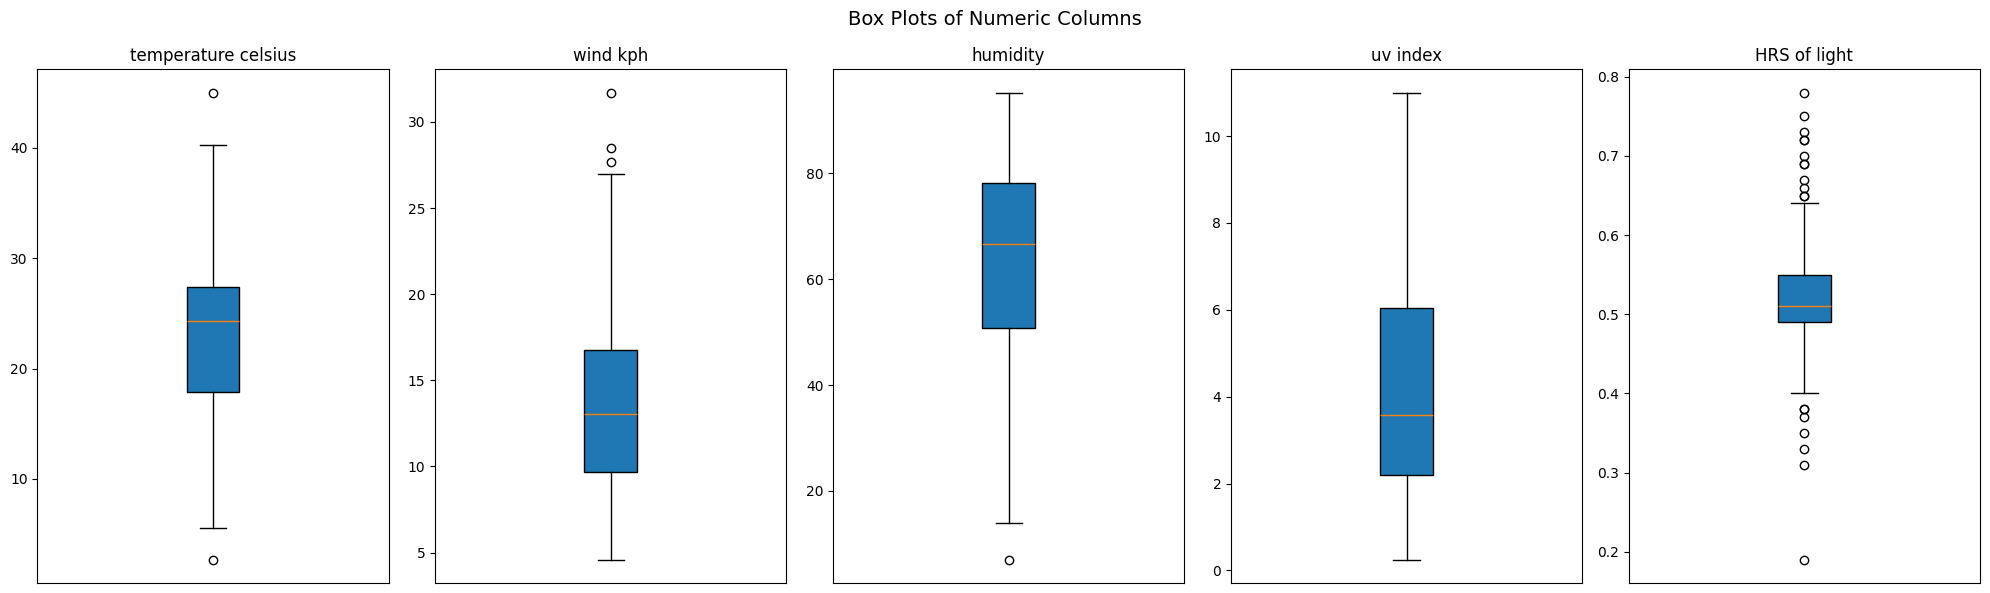

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))
fig.suptitle('Box Plots of Numeric Columns', fontsize=14)

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(weather_clean[col].dropna(), patch_artist=True)
    ax.set_title(col.replace('_', ' '))
    ax.set_xticks([])

plt.tight_layout()
plt.show()


Going through all outliers they all make sense in my opinion : 
The outlier in temperature celsius refers to Saudi Arabien with a temperature of 45 degrees. According to https://www.visitsaudi.com/en/stories/climate-and-seasons from june to september ""the average hovering around 45 degrees C". So this is accurate piece of data and doesn't make sense to remove it or replace with mean as it would not accurate represent its climate

The other outlier appears to be Canada with 5 degrees celsius. According to https://www.studycanada.ca/english/climate.htm "Daytime summer temperatures can rise to 35°C and higher, while lows of -25°C are not uncommon in winter." so averaging that gives us around 10 degrees average so 5°C is a possible temperature so I will keep it.

For Wind one of the values represents Iceland at 28km/h. According to https://rumbomundo.com/weather-in-iceland-temperature-wind-precipitation/#climate_iceland_temperature_wind_precipitation "gusts of more than 50 km/h (30 mph) can happen in any given month, and up to 90 km/h (56 mph) in the winter months. " These extreme values most likely dragged up the average wind kph to 28 but I will still keep it in.

For Humidity Saudi Arabien was given a humidity level of 7 which, according to https://weatherspark.com/h/y/104018/2023/Historical-Weather-during-2023-in-Riyadh-Saudi-Arabia its safe to say this should be in the 30s at least so i will go ahead and set this value to 30.

According to below Iceland had an average of 0.19 (4.56) hrs of sunlight on average and Sweden had roughly 18.72 hrs of light on average , these values seem to be heavily skewed due to seasonal conditions and seem to be invalid. However , I do eventually decide to drop this data due to high VIF and the fact that I realize its a poor indicator for choosing the best holiday. Knowing that and also due to not having enough time im not going to handle this data since i eventually drop it.

In [34]:
# HRS_of_light outlier check using IQR
q1 = weather_clean['HRS_of_light'].quantile(0.25)
q3 = weather_clean['HRS_of_light'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

hrs_of_light_outliers = weather_clean[
    (weather_clean['HRS_of_light'] < lower_bound) |
    (weather_clean['HRS_of_light'] > upper_bound)
][['country', 'HRS_of_light']].sort_values('HRS_of_light', ascending=False)

print('HRS_of_light outlier country and value:')
if hrs_of_light_outliers.empty:
    print('No HRS_of_light outliers found using the IQR rule.')
else:
    print(hrs_of_light_outliers.to_string(index=False))

HRS_of_light outlier country and value:
       country  HRS_of_light
        Sweden          0.78
       Estonie          0.75
        Russia          0.73
     Lithuania          0.72
       Letonia          0.72
       Germany          0.70
       Belgium          0.69
United Kingdom          0.69
        France          0.67
       Croatia          0.66
        Canada          0.65
        Serbia          0.65
   New Zealand          0.38
     Macedonia          0.38
    San Marino          0.37
 Liechtenstein          0.35
    Kazakhstan          0.33
       Belarus          0.31
       Iceland          0.19


In [35]:
# Update Saudi Arabia humidity to 30 and print the updated line
country_mask = weather_clean['country'].isin(['Saudi Arabien', 'Saudi Arabia'])
weather_clean.loc[country_mask, 'humidity'] = 30

print('Updated row(s):')
updated_rows = weather_clean.loc[country_mask, ['country', 'humidity']]
if updated_rows.empty:
    print('No row found for Saudi Arabien or Saudi Arabia.')
else:
    print(updated_rows.to_string(index=False))

Updated row(s):
      country  humidity
 Saudi Arabia      30.0
Saudi Arabien      30.0


## 10. Final Dataset Preview and checks

A quick look at the fully cleaned and prepared dataset.

In [36]:
# Statistical summary of the fully cleaned dataset.
print("Statistical Summary:")
print(weather_clean[numeric_cols].describe().round(2).to_string())


Statistical Summary:
       temperature_celsius  wind_kph  humidity  uv_index  HRS_of_light
count               201.00    201.00    201.00    201.00        201.00
mean                 22.70     13.56     64.21      4.18          0.52
std                   6.94      5.23     18.34      2.73          0.08
min                   2.68      4.59     14.00      0.25          0.19
25%                  17.90      9.65     50.81      2.19          0.49
50%                  24.30     13.03     66.74      3.58          0.51
75%                  27.41     16.74     78.18      6.04          0.55
max                  45.00     31.70     95.25     11.00          0.78


In [37]:
# Final confirmation that the dataset is fully clean and ready for analysis.
print("Final Dataset Info:")
print("-" * 40)
weather_clean.info()


Final Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              201 non-null    str    
 1   temperature_celsius  201 non-null    float64
 2   wind_kph             201 non-null    float64
 3   humidity             201 non-null    float64
 4   uv_index             201 non-null    float64
 5   condition_text       201 non-null    str    
 6   condition_category   201 non-null    str    
 7   condition_score      201 non-null    int64  
 8   HRS_of_light         201 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 14.3 KB


In [38]:
weather_clean.head(10)

,country,temperature_celsius,wind_kph,humidity,uv_index,condition_text,condition_category,condition_score,HRS_of_light
0,Afghanistan,18.754247,10.340000,28.046575,4.694795,sunny,Clear,5,0.60
1,Albania,21.625479,9.776438,50.805479,4.181096,sunny,Clear,5,0.46
2,Algeria,22.275068,14.090685,58.019178,3.846849,partly cloudy,Partly Cloudy,4,0.50
3,Andorra,10.402192,9.050137,61.750685,2.798630,sunny,Clear,5,0.46
4,Angola,27.371233,11.057808,70.923288,6.942192,partly cloudy,Partly Cloudy,4,0.49
5,Antigua And Barbuda,26.745479,22.950959,78.219178,2.157260,partly cloudy,Partly Cloudy,4,0.45
6,Argentina,15.151781,10.493973,82.221918,1.733699,sunny,Clear,5,0.41
7,Armenia,18.325205,7.910411,38.172603,4.780548,partly cloudy,Partly Cloudy,4,0.51
8,Australia,12.974247,10.600274,74.123288,0.417534,clear,Clear,5,0.61
9,Austria,14.389589,14.013973,62.309589,3.298630,partly cloudy,Partly Cloudy,4,0.55


In [39]:
weather_clean.to_csv('../Cleaned_Csvs/Cleaned_Global_Weather.csv', index=False)
print("Saved to Cleaned_Csvs/Cleaned_Global_Weather.csv")


Saved to Cleaned_Csvs/Cleaned_Global_Weather.csv


## 11. Multivariate Assessment for Index Integration

This section evaluates the environmental variables to assess their readiness for inclusion in the composite "Best Country to Visit" index. Special attention is paid to multicollinearity and variable retention decisions.


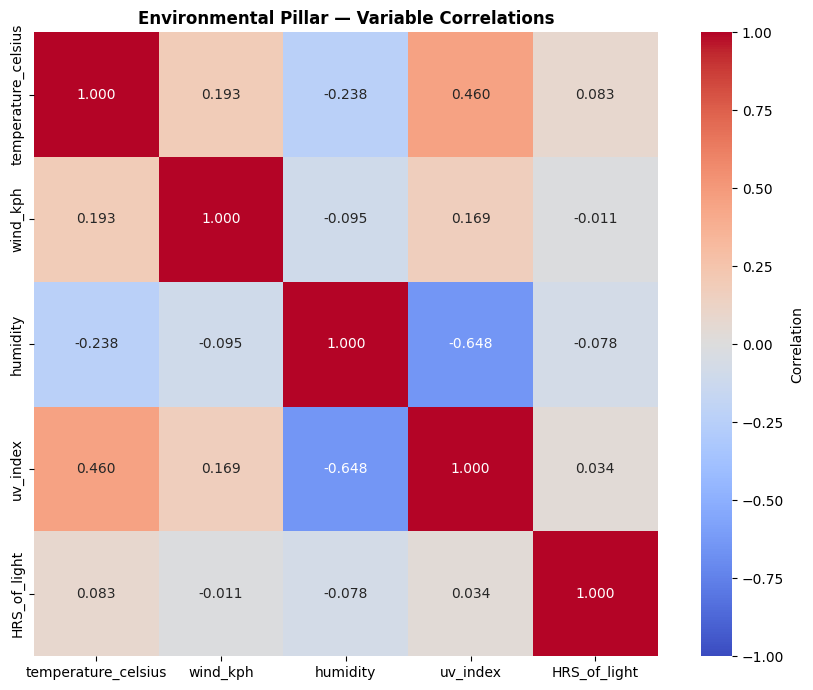

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to assess
numeric_cols = ['temperature_celsius', 'wind_kph', 'humidity', 'uv_index', 'HRS_of_light']
environment_data = weather_clean[numeric_cols]

# Correlation heatmap
corr_matrix = environment_data.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Environmental Pillar — Variable Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Data Source

This weather dataset is sourced from Kaggle's Global Weather Repository and provides country-level weather observations used to build climate indicators for the holiday index.

Source: https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository

## 13. References

Python Software Foundation (2024) *unicodedata — Unicode Database*. Available at: [https://docs.python.org/3/library/unicodedata.html](https://docs.python.org/3/library/unicodedata.html) (Accessed: 16 April 2026).

deep_translator Documentation (2024) *Google Translate*. Available at: [https://deep-translator.readthedocs.io/en/latest/usage.html#google-translate](https://deep-translator.readthedocs.io/en/latest/usage.html#google-translate) (Accessed: 16 April 2026).